In [20]:
import sys
sys.path.append("../..")
from src.sawmill.sawmill import Sawmill
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [21]:
s = Sawmill("../../datasets_raw/tpc-ds/work_mem_2_256kB_2_128kB_parallel_1_2.log", workdir="../datasets/tpc-ds")
s.parse(regex_dict={"ID" : r'(?<=EDT \[ )\S{14}',"Timestamp": r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}'}, force=True, message_prefix=r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}.\d{3}')

Initialized Sawmill with log file ../../datasets_raw/tpc-ds/work_mem_2_256kB_2_128kB_parallel_1_2.log
Work directory set to ../datasets/tpc-ds
Parsing file: ../../datasets_raw/tpc-ds/work_mem_2_256kB_2_128kB_parallel_1_2.log


Extracting variables from each line...: 100%|██████████| 100/100 [00:00<00:00, 411.71it/s]


Variables generated from regexes: 2
Variables generated by Drain: 160
Templates with at least 1 non-regex variable: 100
Templates with at least 2 occurrences: 99


Casting datetime variables...:   0%|          | 0/1 [00:00<?, ?it/s]~/.local/lib/python3.11/site-packages/tqdm/std.py:915: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return func(*args, **kwargs)
Dumping _parsed_variables to pkl file...: 100%|██████████| 1/1 [00:00<00:00, 1109.31it/s]

Parsing complete in 1.131086 seconds!


'1.131086'

In [22]:
s._parsed_variables.head(15)

,Name,Tag,Type,Occurrences,Preceding 3 tokens,Examples,From regex
0,ID,ID,str,4687,[],"[6542c92d.1f943, 6542d880.1fc1b, 6542e76c.1fe63, 6543018c.20227, 65431bc7.20615]",True
1,Timestamp,Timestamp,date,4687,[],"[2023-11-01 17:54:53.006, 2023-11-01 17:54:53.017, 2023-11-01 17:54:53.018, 2023-11-01 17:54:53.019, 2023-11-01 17:54:53.027]",True
2,3dad7fac_22,port,num,8,"[127.0.0.1, port, =]","[42396, 51214, 54898, 47566, 60122]",False
3,ce7e95f9_4,ce7e95f9_4,str,8,"[EDT, [, <*0>]","[3/5183, 3/5281, 3/5379, 3/5477, 3/5575]",False
4,ecde4441_4,ecde4441_4,str,8,"[EDT, [, <*0>]","[3/5183, 3/5281, 3/5379, 3/5477, 3/5575]",False
5,be64f0a7_4,be64f0a7_4,str,1552,"[EDT, [, <*0>]","[3/5184, 3/5185, 3/5186, 3/5187, 3/5188]",False
6,be64f0a7_11,statement,str,1552,"[:, statement, :]","[BEGIN, COMMIT]",False
7,caf9d557_4,caf9d557_4,str,2327,"[EDT, [, <*0>]","[3/5184, 3/0, 3/5185, 3/5186, 3/5187]",False
8,caf9d557_11,duration,num,2327,"[:, duration, :]","[0.076, 0.062, 0.030, 0.023, 0.044]",False
9,3c554967_4,3c554967_4,str,8,"[EDT, [, <*0>]","[3/5184, 3/5282, 3/5380, 3/5478, 3/5576]",False


In [23]:
s.set_causal_unit("ID")
s.prepare(force = True)

Causal unit set to ID (tag: ID)
Calculating aggregates for each causal unit...


Dumping _prepared_variables to pkl file...: 100%|██████████| 1/1 [00:00<00:00, 687.37it/s]

Successfully prepared the log with causal unit ID 
            (tag: ID)
Preparation complete in 1.733003 seconds!


'1.733003'

In [24]:
s._prepared_log

,cui,Timestamp+earliest,3dad7fac_22+mean,3dad7fac_22+min,3dad7fac_22+max,caf9d557_11+mean,caf9d557_11+min,caf9d557_11+max,3c554967_14+mean,3c554967_14+min,3c554967_14+max,55a934b8_15+mean,55a934b8_15+min,55a934b8_15+max,e0e90387_25+mean,e0e90387_25+min,e0e90387_25+max,ce7e95f9_4+latest=3/5183,ce7e95f9_4+latest=3/5281,ce7e95f9_4+latest=3/5379,ce7e95f9_4+latest=3/5477,ce7e95f9_4+latest=3/5575,ce7e95f9_4+latest=3/5673,ce7e95f9_4+latest=3/5771,ce7e95f9_4+latest=3/5869,ecde4441_4+latest=3/5183,ecde4441_4+latest=3/5281,ecde4441_4+latest=3/5379,ecde4441_4+latest=3/5477,ecde4441_4+latest=3/5575,ecde4441_4+latest=3/5673,ecde4441_4+latest=3/5771,ecde4441_4+latest=3/5869,be64f0a7_4+latest=3/5280,be64f0a7_4+latest=3/5378,be64f0a7_4+latest=3/5476,be64f0a7_4+latest=3/5574,be64f0a7_4+latest=3/5672,be64f0a7_4+latest=3/5770,be64f0a7_4+latest=3/5868,be64f0a7_4+latest=3/5966,be64f0a7_11+latest=COMMIT,caf9d557_4+latest=3/0,3c554967_4+latest=3/5184,3c554967_4+latest=3/5282,3c554967_4+latest=3/5380,3c554967_4+latest=3/5478,3c554967_4+latest=3/5576,3c554967_4+latest=3/5674,3c554967_4+latest=3/5772,3c554967_4+latest=3/5870,55a934b8_4+latest=3/5185,55a934b8_4+latest=3/5283,55a934b8_4+latest=3/5381,55a934b8_4+latest=3/5479,55a934b8_4+latest=3/5577,55a934b8_4+latest=3/5675,55a934b8_4+latest=3/5773,55a934b8_4+latest=3/5871,86755a9f_4+latest=3/5186,86755a9f_4+latest=3/5284,86755a9f_4+latest=3/5382,86755a9f_4+latest=3/5480,86755a9f_4+latest=3/5578,86755a9f_4+latest=3/5676,86755a9f_4+latest=3/5774,86755a9f_4+latest=3/5872,8ddfd19b_4+latest=3/5187,8ddfd19b_4+latest=3/5285,8ddfd19b_4+latest=3/5383,8ddfd19b_4+latest=3/5481,8ddfd19b_4+latest=3/5579,8ddfd19b_4+latest=3/5677,8ddfd19b_4+latest=3/5775,8ddfd19b_4+latest=3/5873,2a54942b_4+latest=3/5188,2a54942b_4+latest=3/5286,2a54942b_4+latest=3/5384,2a54942b_4+latest=3/5482,2a54942b_4+latest=3/5580,2a54942b_4+latest=3/5678,2a54942b_4+latest=3/5776,2a54942b_4+latest=3/5874,e933b81c_4+latest=3/5189,e933b81c_4+latest=3/5287,e933b81c_4+latest=3/5385,e933b81c_4+latest=3/5483,e933b81c_4+latest=3/5581,e933b81c_4+latest=3/5679,e933b81c_4+latest=3/5777,e933b81c_4+latest=3/5875,4dff267e_4+latest=3/5190,4dff267e_4+latest=3/5288,4dff267e_4+latest=3/5386,4dff267e_4+latest=3/5484,4dff267e_4+latest=3/5582,4dff267e_4+latest=3/5680,4dff267e_4+latest=3/5778,4dff267e_4+latest=3/5876,515eb2e6_4+latest=3/5231,515eb2e6_4+latest=3/5329,515eb2e6_4+latest=3/5427,515eb2e6_4+latest=3/5525,515eb2e6_4+latest=3/5623,515eb2e6_4+latest=3/5721,515eb2e6_4+latest=3/5819,515eb2e6_4+latest=3/5917,515eb2e6_14+latest=query020.sql,515eb2e6_28+latest=cs_ext_sales_price,515eb2e6_35+latest=cs_ext_sales_price,515eb2e6_41+latest=cs_ext_sales_price,515eb2e6_53+latest=catalog_sales,515eb2e6_59+latest=cs_item_sk,515eb2e6_79+latest=cs_sold_date_sk,ede23086_4+latest=3/5192,ede23086_4+latest=3/5290,ede23086_4+latest=3/5388,ede23086_4+latest=3/5486,ede23086_4+latest=3/5584,ede23086_4+latest=3/5682,ede23086_4+latest=3/5780,ede23086_4+latest=3/5878,b0920541_4+latest=3/5193,b0920541_4+latest=3/5291,b0920541_4+latest=3/5389,b0920541_4+latest=3/5487,b0920541_4+latest=3/5585,b0920541_4+latest=3/5683,b0920541_4+latest=3/5781,b0920541_4+latest=3/5879,7d19c0d6_4+latest=3/5194,7d19c0d6_4+latest=3/5292,7d19c0d6_4+latest=3/5390,7d19c0d6_4+latest=3/5488,7d19c0d6_4+latest=3/5586,7d19c0d6_4+latest=3/5684,7d19c0d6_4+latest=3/5782,7d19c0d6_4+latest=3/5880,ef13a18a_4+latest=3/5195,ef13a18a_4+latest=3/5293,ef13a18a_4+latest=3/5391,ef13a18a_4+latest=3/5489,ef13a18a_4+latest=3/5587,ef13a18a_4+latest=3/5685,ef13a18a_4+latest=3/5783,ef13a18a_4+latest=3/5881,1479081e_4+latest=3/5196,1479081e_4+latest=3/5294,1479081e_4+latest=3/5392,1479081e_4+latest=3/5490,1479081e_4+latest=3/5588,1479081e_4+latest=3/5686,1479081e_4+latest=3/5784,1479081e_4+latest=3/5882,6231ddc9_4+latest=3/5197,6231ddc9_4+latest=3/5295,6231ddc9_4+latest=3/5393,6231ddc9_4+latest=3/5491,6231ddc9_4+latest=3/5589,6231ddc9_4+latest=3/5687,6231ddc9_4+latest=3/5785,6231ddc9_4+latest=3/5883,28997c13_4+latest=3/5198,28997c13_4+lat

In [26]:
c = s.explore_candidate_causes("caf9d557_11+mean")
c.show(10)

~/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:2412: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 52823.41877534003, tolerance: 41175.81141072582
  ) = cd_fast.enet_coordinate_descent_multi_task(
~/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:2412: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 52588.793730627265, tolerance: 41175.81141072582
  ) = cd_fast.enet_coordinate_descent_multi_task(


,Candidate,ATE,P-value,Standard Error,Tag
0,55a934b8_15+mean,-100.525674,0.000029,[8.910349890405694],55a934b8_15
1,3c554967_14+mean,9990.997321,0.055041,[4204.343578984454],max_parallel_workers
2,a2932dc2_4+latest=3/5659,-11785.652339,0.164026,[7435.042039466132],a2932dc2_4
3,ea7b336b_4+latest=0,-11785.652339,0.164026,[7435.042039466132],ea7b336b_4
4,e0e90387_13+latest=0;13;28.713,-11785.652339,0.164026,[7435.042039466132],time
5,Timestamp+earliest,-0.324999,0.303120,[0.28859361014770835],Timestamp
6,3dad7fac_22+mean,-0.145989,0.745097,[0.4287697565899909],port
7,e0e90387_25+mean,-0.145989,0.745097,[0.4287697565899909],port
8,e5ed2f8f_4+latest=3/5259,529.364685,0.954263,[8853.440714084449],e5ed2f8f_4
9,e2a348e8_4+latest=3/5260,529.364685,0.954263,[8853.440714084449],e2a348e8_4


In [27]:
c.inspect(0)

Information about prepared variable 55a934b8_15+mean:

--> Variable Information about 55a934b8_15:


,Name,Tag,Type,Occurrences,Preceding 3 tokens,Examples,From regex,Aggregates
12,55a934b8_15,55a934b8_15,num,8,"[work_mem, =, ']","[128.0, 64.0, 256.0]",False,"[mean, min, max]"


--> Template Information about 55a934b8:


,TemplateText,TemplateId,Occurrences,VariableIndices,RegexIndices
6,<*1> EDT [ <*0> <*> ] postgres@tpcds1 LOG : statement : SET work_mem = ' <*> ' ;,55a934b8,8,"[4, 15]","[3, 0]"


--> Causal Unit Partial Information:


,cui,caf9d557_11+mean (outcome),55a934b8_15+mean (candidate)
0,6542c92d.1f943,13483.595990,128.0
1,6542d880.1fc1b,13126.180309,128.0
2,6542e76c.1fe63,22983.408399,64.0
3,6543018c.20227,23075.070997,64.0
4,65431bc7.20615,2707.956093,256.0
5,65431ef0.2073a,2781.880526,256.0
6,6543221a.2085f,13000.099663,128.0
7,654330e1.20b8f,13005.023144,128.0


In [37]:
c.inspect(1)

Information about prepared variable 3c554967_14+mean:

--> Variable Information about 3c554967_14:


,Name,Tag,Type,Occurrences,Preceding 3 tokens,Examples,From regex,Aggregates
10,3c554967_14,max_parallel_workers,num,8,"[SET, max_parallel_workers, =]","[1, 2]",False,"[mean, min, max]"


--> Template Information about 3c554967:


,TemplateText,TemplateId,Occurrences,VariableIndices,RegexIndices
5,<*1> EDT [ <*0> <*> ] postgres@tpcds1 LOG : statement : SET max_parallel_workers = <*> ;,3c554967,8,"[4, 14]","[3, 0]"


--> Causal Unit Partial Information:


,cui,caf9d557_11+mean (outcome),3c554967_14+mean (candidate)
0,6542c92d.1f943,13483.595990,1.0
1,6542d880.1fc1b,13126.180309,1.0
2,6542e76c.1fe63,22983.408399,2.0
3,6543018c.20227,23075.070997,2.0
4,65431bc7.20615,2707.956093,1.0
5,65431ef0.2073a,2781.880526,1.0
6,6543221a.2085f,13000.099663,2.0
7,654330e1.20b8f,13005.023144,2.0



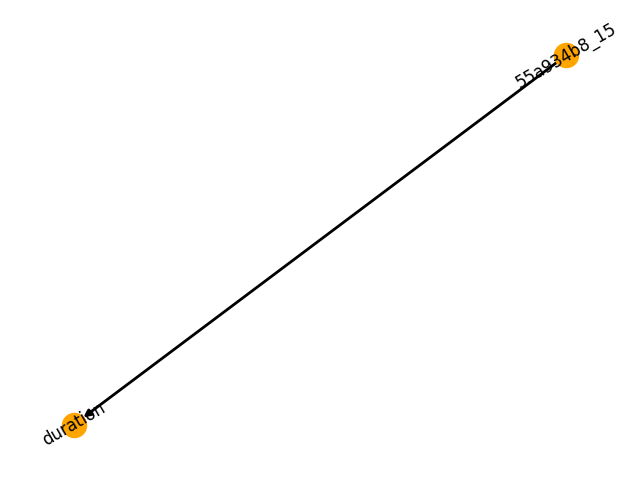

''

In [28]:
c.accept(0)


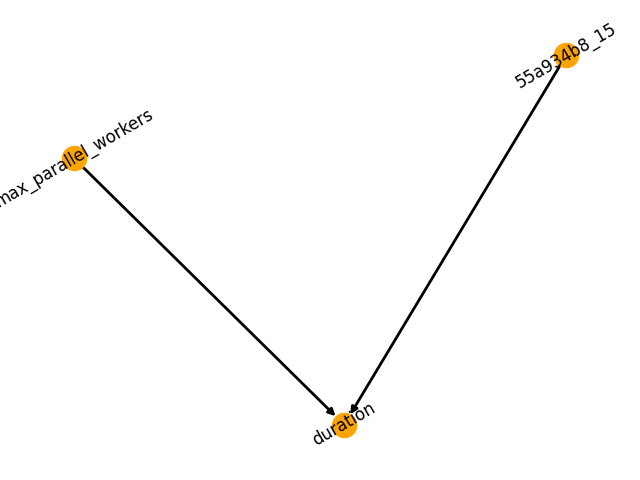

''

In [30]:
c.accept(1)

In [36]:
t = s._prepared_log[["55a934b8_15+mean", "3c554967_14+mean", "caf9d557_11+mean"]]
t.columns = ["work_mem", "max_parallel_workers", "mean_latency"]
t

,work_mem,max_parallel_workers,mean_latency
0,128.0,1.0,13483.595990
1,128.0,1.0,13126.180309
2,64.0,2.0,22983.408399
3,64.0,2.0,23075.070997
4,256.0,1.0,2707.956093
5,256.0,1.0,2781.880526
6,128.0,2.0,13000.099663
7,128.0,2.0,13005.023144


In [33]:
# Max parallel workers
s.get_unadjusted_ate("3c554967_14+mean", "caf9d557_11+mean")

In [34]:
# Max parallel workers
s.get_adjusted_ate("3c554967_14+mean", "caf9d557_11+mean")